# LLM-based TTS

# Agenda
1. [TortoiseTTS](#TortoiseTTS)
1. [Overview](#overview-of-tts-systems)
1. [Creating LLM TTS](#own-small-tts)
1. [Homework](#Homework) 

# Intro

# TortoiseTTS

DALL-E inspired TTS
 
paper: [Better speech synthesis through scaling](https://arxiv.org/pdf/2305.07243)

## Ideas


1. LLM for core generation (GPT2)
1. Diffusion for details rendering 
1. Large pretraining


Questions to answer:
1. How to represent audio to make use of LLM?
1. How to condition generations on text?
1. How to condition on speaker? 
1. How to reconstruct audio from generated tokens?


## General inference scheme


![image.png](attachment:image.png)


## 1. VQ-VAE


paper: [Neural Discrete Representation Learning](https://arxiv.org/pdf/1711.00937)

![image.png](attachment:image.png)

![image.png](attachment:image.png)


## Autoregressive Transformer


BPE 

check whisper lection

* causal attention
* transformer blocks
* shift loss

![image.png](attachment:image.png)

## Speaker conditioning

![image.png](attachment:image.png)

## Diffusion decoder

* DDIM
* latent input fine-tuning
* 

## CLVP

Contrastive Language-Voice Pretrained Transformer, inspired by CLIP

paper: [Learning Transferable Visual Models From Natural Language Supervision](https://arxiv.org/pdf/2103.00020)

* pretraining on matching pairs
* symmetric cross-entropy loss

Given a batch of N (image, text) pairs, CLIP is trained to predict which of the N × N possible (image, text) pairings across a batch actually occurred. To do this, CLIP learns a multi-modal embedding space by jointly training an image encoder and text encoder to maximize the cosine similar- ity of the image and text embeddings of the N real pairs in the batch while minimizing the cosine similarity of the embeddings of the N2 − N incorrect pairings.

![image.png](attachment:image.png)

# Overview of TTS systems

## VALL-E (2023)

paper: [Neural Codec Language Models are Zero-Shot Text to Speech Synthesizers](https://arxiv.org/pdf/2301.02111)

* codec with RVQ
* AR transformer for the first RVQ layer
* non-AR transformer for all other layers
* speaker conditioning without separate encoder

### Encodec

![image.png](attachment:image.png)

### VALL-E

![image.png](attachment:image.png)

## xTTS v2 (2024)

paper: [XTTS: a Massively Multilingual Zero-Shot Text-to-Speech Model](https://arxiv.org/pdf/2406.04904) 

* pretrained speaker encoder
* cnn decoder

![image.png](attachment:image.png)

## CosyVoice 2 (2024)

paper: [CosyVoice 2: Scalable Streaming Speech Synthesis with Large Language Models](https://arxiv.org/pdf/2412.10117)

* Finite scalar quantization (FSQ) for VQ-VAE
* 


![image.png](attachment:image.png)

## Parler TTS (2024)

paper: [Natural language guidance of high-fidelity text-to-speech with synthetic annotations](https://arxiv.org/pdf/2402.01912)

* AR for all RVQ layers with delayed pattern
* Speaker conditioning via cross-attention

In [1]:
# This cell was a leftover demo snippet (ParlerTTS) and breaks "Run all".
# It is not needed for the LM-TTS homework pipeline below.
pass

In [2]:
# Inference helpers: sampling sweeps
import numpy as np
import torch

@torch.no_grad()
def sample_tts_with_params(text, max_new=400, temperature=0.9, top_k=50):
    # Always match *model* device (don't rely on global `device` after moving `tts` around)
    model_device = next(tts.parameters()).device
    text_ids = torch.tensor(
        tokenizer.encode(text, add_special_tokens=False),
        device=model_device,
    )
    toks = tts.generate_audio(text_ids, max_new_tokens=max_new, temperature=temperature, top_k=top_k)
    if toks.numel() == 0:
        return np.zeros(CODEC_SR // 2, dtype=np.float32), toks

    # FocalCodec buffers may live on CPU; ensure tokens on the same device as the codec
    codec_device = next(codec.parameters()).device
    toks = toks.to(codec_device)
    wav = (
        codec.toks_to_sig(toks.unsqueeze(0))
        .squeeze(0)
        .detach()
        .cpu()
        .numpy()
        .astype(np.float32)
    )
    return wav, toks

# Example sweep
# texts = ["Hello world.", "Neural codecs discretize audio."]
# params = [
#     dict(temperature=0.7, top_k=20),
#     dict(temperature=0.9, top_k=50),
#     dict(temperature=1.0, top_k=100),
# ]
# generations = []
# for t in texts:
#     for p in params:
#         wav, toks = sample_tts_with_params(t, max_new=400, **p)
#         generations.append({'text': t, **p, 'wav': wav, 'toks': toks})

![image.png](attachment:image.png)

# Training LLM TTS 

* Flattened encodec with 2 quantizers 
* bpe tokenizer 
* gpt2
* native decoder

## 1. Dataset

LJspeech: https://www.kaggle.com/datasets/mathurinache/the-lj-speech-dataset

In [3]:
import os
import glob
import tarfile
import torchaudio

root_dir = "./data"
os.makedirs(root_dir, exist_ok=True)

# Create dataset object (downloads archive if needed)
ljspeech_dataset = torchaudio.datasets.LJSPEECH(root=root_dir, download=True)

# Torchaudio expects extracted folder: {root}/LJSpeech-1.1/wavs/
expected_wavs_dir = os.path.join(root_dir, "LJSpeech-1.1", "wavs")
expected_first_wav = os.path.join(expected_wavs_dir, "LJ001-0001.wav")

# If extraction didn't happen, extract manually from the downloaded archive.
if not os.path.exists(expected_first_wav):
    print("LJ Speech wavs not found at", expected_wavs_dir)

    archives = (
        glob.glob(os.path.join(root_dir, "*.tar.bz2"))
        + glob.glob(os.path.join(root_dir, "**", "*.tar.bz2"), recursive=True)
    )
    archives = sorted(set(archives))
    if len(archives) == 0:
        raise RuntimeError(
            f"No LJSpeech archive (*.tar.bz2) found under {root_dir}. "
            "Re-run the cell with download=True or check disk quota."
        )

    archive = max(archives, key=lambda p: os.path.getsize(p))
    print("Extracting", archive, "->", root_dir)

    with tarfile.open(archive, "r:bz2") as tf:
        tf.extractall(path=root_dir)

    if not os.path.exists(expected_first_wav):
        raise RuntimeError("Expected wav still missing: " + expected_first_wav)

# Now it must work
waveform, sample_rate, transcript, normalized_transcript = ljspeech_dataset[0]
print("Waveform shape:", waveform.shape)
print("Sample rate:", sample_rate)
print("Transcript:", transcript)

LJ Speech wavs not found at ./data/LJSpeech-1.1/wavs
Extracting ./data/LJSpeech-1.1.tar.bz2 -> ./data


/tmp/ipykernel_257/3231620352.py:35: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(path=root_dir)


Waveform shape: torch.Size([1, 212893])
Sample rate: 22050
Transcript: Printing, in the only sense with which we are at present concerned, differs from most if not from all the arts and crafts represented in the Exhibition


In [4]:
import IPython.display as ipd

ipd.display(ipd.Audio(waveform, rate=sample_rate))

In [5]:
import pandas as pd
import numpy as np

meta = pd.read_csv(f'{root_dir}/LJSpeech-1.1/metadata.csv', sep='|', header=None,
                   names=['id', 'text', 'text_norm'])
meta['text_norm'] = meta['text_norm'].fillna(meta['text'])
meta['filepath'] = meta['id'].apply(lambda s: f'{root_dir}/LJSpeech-1.1/wavs/{s}.wav')

rng = np.random.default_rng(42)
perm = rng.permutation(len(meta))
split_at = int(0.9 * len(meta))
train_df = meta.iloc[perm[:split_at]].reset_index(drop=True)
val_df   = meta.iloc[perm[split_at:]].reset_index(drop=True)
print(f'train: {len(train_df)}  val: {len(val_df)}')
train_df.head(2)

train: 11790  val: 1310


,id,text,text_norm,filepath
0,LJ022-0092,and such projects as they approve will be next...,and such projects as they approve will be next...,./data/LJSpeech-1.1/wavs/LJ022-0092.wav
1,LJ039-0028,"was shipped from Los Angeles on March 20, 1963...","was shipped from Los Angeles on March twenty, ...",./data/LJSpeech-1.1/wavs/LJ039-0028.wav


## 2. Audio codec

In [6]:
# Kaggle-friendly: focalcodec is NOT on PyPI.
# Install it from GitHub if missing.
import sys
import subprocess

try:
    from focalcodec import FocalCodec
except ModuleNotFoundError:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "-q",
            "install",
            "focalcodec@git+https://github.com/lucadellalib/focalcodec.git@main#egg=focalcodec",
        ]
    )
    from focalcodec import FocalCodec

import torch
import librosa
import matplotlib.pyplot as plt
import soundfile as sf
import torchaudio


device = "cuda" if torch.cuda.is_available() else "cpu"

DEPRECATION: omegaconf 2.0.6 has a non-standard dependency specifier PyYAML>=5.1.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of omegaconf or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/577M [00:00<?, ?B/s]

codebook=8192, sr_in/out=16000/16000
LJ003-0083: 6.50s -> 162 tokens


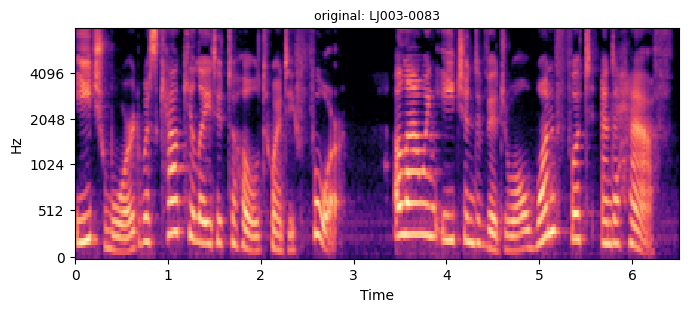

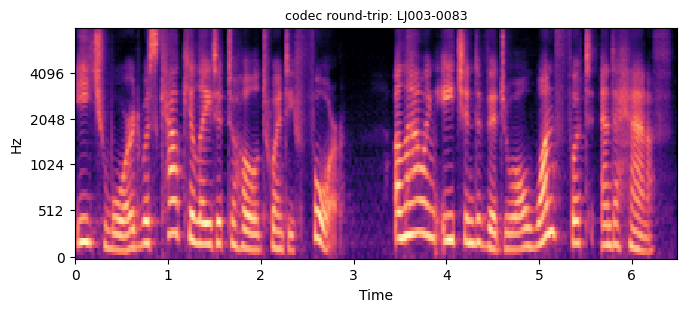

In [7]:
codec = FocalCodec.from_pretrained('lucadellalib/focalcodec_25hz').to(device).eval()
for p in codec.parameters(): p.requires_grad_(False)
CODEBOOK_SIZE = int(codec.codebook.shape[0])
CODEC_SR = codec.sample_rate_input
print(f'codebook={CODEBOOK_SIZE}, sr_in/out={CODEC_SR}/{codec.sample_rate_output}')

def load_wav_16k(path):
    arr, sr = sf.read(path, dtype='float32', always_2d=False)
    if arr.ndim > 1: arr = arr.mean(-1)
    wav = torch.from_numpy(arr)
    if sr != CODEC_SR: wav = torchaudio.functional.resample(wav, sr, CODEC_SR)
    return wav  # (T,)

def plot_mel(wav, sr, title=''):
    wav = np.asarray(wav).astype(np.float32)
    if wav.ndim > 1: wav = wav.mean(0)
    S = librosa.feature.melspectrogram(y=wav, sr=sr, n_fft=1024, hop_length=256,
                                       n_mels=80, fmin=50, fmax=sr//2)
    fig, ax = plt.subplots(figsize=(max(6, len(wav)/sr*1.2), 3))
    librosa.display.specshow(librosa.power_to_db(S, ref=np.max), sr=sr, hop_length=256,
                              x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(title, fontsize=9); plt.show()

row = val_df.iloc[0]
wav = load_wav_16k(row['filepath']).to(device)
with torch.no_grad():
    toks = codec.sig_to_toks(wav.unsqueeze(0))
    rec = codec.toks_to_sig(toks).squeeze(0).detach().cpu().numpy()
print(f'{row["id"]}: {wav.shape[-1]/CODEC_SR:.2f}s -> {toks.shape[-1]} tokens')
plot_mel(wav.cpu().numpy(), CODEC_SR, f'original: {row["id"]}')
plot_mel(rec, codec.sample_rate_output, f'codec round-trip: {row["id"]}')

# 3. Precompute features

In [8]:
from tqdm.auto import tqdm
from transformers import GPT2TokenizerFast

In [9]:
tokenizer = GPT2TokenizerFast.from_pretrained('gpt2')

CACHE_DIR = os.path.join(root_dir, 'tokenized')
os.makedirs(CACHE_DIR, exist_ok=True)
TRAIN_CACHE = os.path.join(CACHE_DIR, 'train.pt')
VAL_CACHE   = os.path.join(CACHE_DIR, 'val.pt')


# Kaggle tip: set this to None to tokenize full split
MAX_ROWS_PER_SPLIT = 32

@torch.no_grad()
def encode_split(df, cache_path, batch_size=16, overwrite=False, max_rows=MAX_ROWS_PER_SPLIT):
    if os.path.exists(cache_path) and not overwrite:
        print(f'load cache: {cache_path}')
        return torch.load(cache_path, weights_only=False)

    # Set max_rows=None to precompute on full dataset
    if max_rows is not None:
        df = df.iloc[:max_rows]

    recs = df.to_dict('records')
    paths = [r['filepath'] for r in recs]
    order = np.argsort([os.path.getsize(p) for p in paths])
    out = [None] * len(recs)
    for start in tqdm(range(0, len(recs), batch_size)):
        idxs = order[start:start+batch_size]
        wavs = [load_wav_16k(paths[i]) for i in idxs]
        lens = torch.tensor([w.numel() for w in wavs], dtype=torch.float32)
        L = int(lens.max()); batch = torch.zeros(len(wavs), L)
        for j, w in enumerate(wavs): batch[j, :w.numel()] = w
        batch = batch.to(device)
        toks = codec.sig_to_toks(batch, length=(lens/L).to(device))
        tok_lens = ((lens/L).to(device) * toks.shape[-1]).round().clamp(max=toks.shape[-1]).to(torch.long)
        for j, i in enumerate(idxs):
            text_ids = tokenizer.encode(recs[i]['text_norm'], add_special_tokens=False)
            text_ids = torch.tensor(text_ids, dtype=torch.long)
            audio_ids = toks[j, :tok_lens[j]].to(torch.long).cpu()
            out[i] = {
                'id': recs[i]['id'],
                'text': recs[i]['text_norm'],
                'text_ids': text_ids,
                'audio_ids': audio_ids,
                'n_text': int(text_ids.numel()),
                'n_audio': int(audio_ids.numel()),
            }

    torch.save(out, cache_path)
    print(f'saved {len(out)} items to {cache_path}')
    return out


print('tokenize train'); train_items = encode_split(train_df, TRAIN_CACHE)
print('tokenize val');   val_items   = encode_split(val_df,   VAL_CACHE)
a = np.array([r['n_audio'] for r in train_items])
t = np.array([r['n_text']  for r in train_items])
print(f'audio tokens: mean={a.mean():.1f} p95={np.percentile(a,95):.0f} max={a.max()}')
print(f'text  tokens: mean={t.mean():.1f} p95={np.percentile(t,95):.0f} max={t.max()}')

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenize train


  0%|          | 0/2 [00:00<?, ?it/s]

saved 32 items to ./data/tokenized/train.pt
tokenize val


  0%|          | 0/2 [00:00<?, ?it/s]

saved 32 items to ./data/tokenized/val.pt
audio tokens: mean=171.6 p95=245 max=252
text  tokens: mean=21.1 p95=32 max=33


In [10]:
from torch.utils.data import Dataset


class TokenizedLJSpeech(Dataset):
    def __init__(self, cache_path, max_total_len=1024):
        items = torch.load(cache_path, weights_only=False)
        self.items = [it for it in items if it["n_text"] + it["n_audio"] + 2 <= max_total_len]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        it = self.items[i]
        return {
            "id": it["id"],
            "text_ids": it["text_ids"].long(),
            "audio_ids": it["audio_ids"].long(),
        }


def collate(batch):
    B = len(batch)
    text_lens = torch.tensor([b["text_ids"].numel() for b in batch], dtype=torch.long)
    audio_lens = torch.tensor([b["audio_ids"].numel() for b in batch], dtype=torch.long)
    text_ids = torch.zeros(B, int(text_lens.max()), dtype=torch.long)
    audio_ids = torch.zeros(B, int(audio_lens.max()), dtype=torch.long)
    for i, b in enumerate(batch):
        text_ids[i, : b["text_ids"].numel()] = b["text_ids"]
        audio_ids[i, : b["audio_ids"].numel()] = b["audio_ids"]
    return {"text_ids": text_ids, "text_lens": text_lens,
            "audio_ids": audio_ids, "audio_lens": audio_lens}

In [11]:
from torch.utils.data import DataLoader

train_ds = TokenizedLJSpeech(TRAIN_CACHE)
val_ds   = TokenizedLJSpeech(VAL_CACHE)
print('train example:', train_ds[0])
print('val   example:', val_ds[0])

train_dl = DataLoader(train_ds, collate_fn=collate, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   collate_fn=collate, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

batch = next(iter(train_dl))
for k, v in batch.items():
    print(k, v.shape)

train example: {'id': 'LJ022-0092', 'text_ids': tensor([  392,   884,  4493,   355,   484, 14762,   481,   307,  1306,  8948,
          284,   262,  1992,   508,   739,   262,  2191,   318,  2672,   284,
          787,  2457, 49157,    13]), 'audio_ids': tensor([7880,  550, 1578, 1642, 5738, 5798, 3240, 7329, 1317, 7123, 7672, 8125,
        2658, 3266, 5956, 5611, 7615, 1910, 5057,  258, 4617, 5766, 5775, 5134,
        2547, 6843, 1571, 1907, 1892, 1621, 3069, 7165, 4788, 5948, 5310,  387,
        1509, 5560, 1602, 7267, 4324, 2619, 6708, 5445, 7059, 5599, 4102, 4127,
        7836, 7836, 7190, 4630, 6226, 2250, 6535, 4503, 3414, 5464, 1802, 6996,
        1782, 3833, 5733, 1735, 2380, 7709, 2701, 6346,  448, 4700, 5372, 3310,
        6313, 5281, 4962, 7203, 6005, 7074, 7624, 5565, 1777, 6109, 8104, 4263,
        5167, 4445, 5121, 5264, 4711, 4590, 7095, 6704, 6335,  303, 1397, 4595,
        7800, 1008, 1127, 1127, 3019, 1463, 4659, 4850, 4819, 7366,  163, 6685,
        5184, 8095, 4106,

# 4. TTS class

In [12]:
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import GPT2LMHeadModel


@dataclass
class GPT2TTSConfig:
    base_model: str = "gpt2"
    codebook_size: int = 8192
    n_special_tokens: int = 2  # BOS, EOS

    @property
    def audio_vocab_size(self) -> int:
        return self.codebook_size + self.n_special_tokens

    @property
    def bos_id(self) -> int:
        return self.codebook_size

    @property
    def eos_id(self) -> int:
        return self.codebook_size + 1


class GPT2TTS(nn.Module):
    def __init__(self, cfg: GPT2TTSConfig):
        super().__init__()
        self.cfg = cfg
        self.base = GPT2LMHeadModel.from_pretrained(cfg.base_model)
        H = self.base.config.n_embd
        V = cfg.audio_vocab_size
        
        self.audio_emb = nn.Embedding(V, H)
        self.audio_head = nn.Linear(H, V, bias=False)
        nn.init.normal_(self.audio_emb.weight, std=0.02)
        nn.init.normal_(self.audio_head.weight, std=0.02)

    def _build_inputs(self, text_ids, text_lens, audio_ids, audio_lens):
        """Pack a variable-length batch into a single (B, L, H) tensor with mask + labels.

        Inputs
        ------
        text_ids   : LongTensor[B, T_text_max]   padded GPT-2 BPE ids
        text_lens  : LongTensor[B]               actual text length per row
        audio_ids  : LongTensor[B, T_audio_max]  padded FocalCodec ids (all < codebook_size)
        audio_lens : LongTensor[B]               actual audio length per row

        Per-row layout (let tl = text_lens[i], al = audio_lens[i]):

            position :  0 .. tl-1   tl     tl+1 .. tl+al    tl+1+al    tl+2+al .. L-1
            content  :   text       BOS         audio          EOS          PAD

        Returns
        -------
        inputs : FloatTensor[B, L, H]
            Embeddings. Text goes through GPT-2's wte; audio/BOS/EOS through self.audio_emb.
        mask   : LongTensor[B, L]
            1 on real tokens, 0 on PAD. This is the `attention_mask` for GPT-2.
        labels : LongTensor[B, L]
            Target audio ids at positions that SHOULD be predicted (audio + EOS),
            and -100 everywhere else (text, BOS, PAD).
            Do NOT apply the causal shift here — `forward` does that.
        """

        # Gotchas
        # - L must be the padded max across the batch: max_i(tl + al + 2).
        # - Padded positions must be 0 in `mask` AND -100 in `labels` (or pass another "ignore" value to loss function)
        # - The BOS position is NOT a label (we don't train to predict BOS from text).
        # - The EOS position IS a label (we want the model to learn when to stop).
        # - text_emb and audio_emb have the same hidden size H — concatenate on time.

        device = text_ids.device
        B = text_ids.size(0)
        H = self.base.config.n_embd

        # padded max length across the batch
        L = int((text_lens + audio_lens + 2).max().item())

        emb_dtype = self.base.transformer.wte.weight.dtype
        inputs = torch.zeros((B, L, H), device=device, dtype=emb_dtype)
        mask = torch.zeros((B, L), device=device, dtype=torch.long)
        labels = torch.full((B, L), -100, device=device, dtype=torch.long)

        for i in range(B):
            tl = int(text_lens[i].item())
            al = int(audio_lens[i].item())

            t = text_ids[i, :tl]
            a = audio_ids[i, :al]

            text_emb = self.base.transformer.wte(t)  # (tl, H)

            bos = torch.full((1,), self.cfg.bos_id, device=device, dtype=torch.long)
            eos = torch.full((1,), self.cfg.eos_id, device=device, dtype=torch.long)
            audio_in = torch.cat([bos, a, eos], dim=0)  # (1+al+1,)
            audio_emb = self.audio_emb(audio_in)  # (1+al+1, H)

            seq_len = tl + 1 + al + 1
            inputs[i, :seq_len] = torch.cat([text_emb, audio_emb], dim=0)
            mask[i, :seq_len] = 1

            # labels: predict audio and EOS, not BOS
            if al > 0:
                labels[i, tl + 1 : tl + 1 + al] = a
            labels[i, tl + 1 + al] = self.cfg.eos_id

        return inputs, mask, labels

    def forward(self, text_ids, text_lens, audio_ids, audio_lens):
        inputs, mask, labels = self._build_inputs(text_ids, text_lens, audio_ids, audio_lens)
        h = self.base.transformer(
            inputs_embeds=inputs, attention_mask=mask, return_dict=True
        ).last_hidden_state
        logits = self.audio_head(h)  # (B, L, V)

        # Compute the causal-LM cross-entropy loss.
        # In a causal LM the hidden state at position t predicts the token at position t+1.
        # Use ignore_index=-100 so masked positions don't contribute. Cast logits to float32
        # before the softmax for numerical stability under bf16/fp16.
        # Expected: a scalar tensor `loss`.

        # causal LM shift: hidden[t] predicts token[t+1]
        shift_logits = logits[:, :-1, :].float().contiguous()
        shift_labels = labels[:, 1:].contiguous()
        loss = F.cross_entropy(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
            ignore_index=-100,
        )

        return {"loss": loss, "logits": logits}  

    @torch.no_grad()
    def generate_audio(self, text_ids, max_new_tokens=400, min_new_tokens=225, temperature=0.9, top_k=50):
        """Autoregressively sample audio tokens conditioned on text.

        Runs [text][BOS] through the transformer once to prime the KV cache,
        leaving `h` as the hidden state after BOS. You write the sampling loop.
        """
        self.eval()
        device = text_ids.device
        text_ids = text_ids.view(-1).long().to(device)
        text_emb = self.base.transformer.wte(text_ids).unsqueeze(0)            # (1, T, H)
        bos = self.audio_emb.weight[self.cfg.bos_id].view(1, 1, -1)            # (1, 1, H)
        prefix = torch.cat([text_emb, bos], dim=1)                             # (1, T+1, H)
        mask = torch.ones(1, prefix.size(1), device=device, dtype=torch.long)

        out = self.base.transformer(
            inputs_embeds=prefix, attention_mask=mask,
            use_cache=True, return_dict=True,
        )
        past = out.past_key_values
        h = out.last_hidden_state[:, -1, :]   # (1, H) — hidden state after BOS

        # Autoregressive sampling loop. Starting from `h` (hidden state after BOS), repeatedly:
        # project to audio-vocab logits, apply temperature + top-k, sample a token, handle
        # stopping, and feed the token back through
        # the transformer using `past`/`mask` to refresh `h`. Stop at EOS or max_new_tokens.
        # Return the collected audio ids as a LongTensor on `device`.

        generated = []
        min_new_tokens = int(max(0, min_new_tokens))

        for step in range(int(max_new_tokens)):
            logits = self.audio_head(h)  # (1, V)
            logits = logits / float(max(1e-8, temperature))

            # Block EOS until minimum duration is reached.
            if step < min_new_tokens:
                logits[:, self.cfg.eos_id] = -float("inf")

            if top_k is not None and top_k > 0:
                k = min(int(top_k), logits.size(-1))
                vals, _ = torch.topk(logits, k, dim=-1)
                thresh = vals[:, -1].unsqueeze(-1)
                logits = torch.where(logits < thresh, torch.full_like(logits, -float("inf")), logits)

            probs = torch.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1).squeeze(-1)
            tid = int(next_id.item())

            if tid == self.cfg.eos_id:
                break
            generated.append(tid)

            emb = self.audio_emb(next_id).view(1, 1, -1)
            mask = torch.ones(1, mask.size(1) + 1, device=device, dtype=torch.long)
            out = self.base.transformer(
                inputs_embeds=emb,
                attention_mask=mask,
                past_key_values=past,
                use_cache=True,
                return_dict=True,
            )
            past = out.past_key_values
            h = out.last_hidden_state[:, -1, :]


        return torch.tensor(generated, dtype=torch.long, device=device)

In [13]:
# Kaggle-friendly installs (uncomment if running on a fresh Kaggle notebook)
# !pip -q install lightning transformers accelerate tokenizers focalcodec soundfile librosa pandas jiwer utmos speechbrain


In [14]:
# Lightning training (minimal)
# Kaggle часто не має пакета `lightning` за замовчуванням.
# Якщо падає імпорт — просто розкоментуй інсталяцію і перезапусти cell.
# !pip -q install lightning

import torch

try:
    import lightning as L
    from lightning.pytorch.callbacks import ModelCheckpoint, LearningRateMonitor
    from lightning.pytorch.loggers import TensorBoardLogger
except ModuleNotFoundError:
    import pytorch_lightning as L  # fallback
    from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor
    from pytorch_lightning.loggers import TensorBoardLogger


class LitGPT2TTS(L.LightningModule):
    def __init__(self, tts: GPT2TTS, lr=2e-4, weight_decay=0.01, warmup_steps=500, max_steps=20000):
        super().__init__()
        self.tts = tts
        self.tts.train()  # avoid starting fit with modules in eval mode
        self.lr = lr
        self.weight_decay = weight_decay
        self.warmup_steps = warmup_steps
        self.max_steps = max_steps

    def on_fit_start(self):
        # If you ran inference before training, `generate_audio()` calls eval().
        # Ensure the model is back in train mode early.
        self.tts.train()

    def training_step(self, batch, batch_idx):
        out = self.tts(**batch)
        self.log('train_loss', out['loss'], prog_bar=True, on_step=True, on_epoch=True)
        return out['loss']

    def validation_step(self, batch, batch_idx):
        out = self.tts(**batch)
        self.log('val_loss', out['loss'], prog_bar=True, on_step=False, on_epoch=True)
        return out['loss']

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=self.weight_decay)

        def lr_lambda(step: int):
            if self.warmup_steps > 0 and step < self.warmup_steps:
                return float(step) / float(max(1, self.warmup_steps))
            if self.max_steps <= 0:
                return 1.0
            # cosine decay to 10%
            import math
            progress = (step - self.warmup_steps) / float(max(1, self.max_steps - self.warmup_steps))
            progress = min(max(progress, 0.0), 1.0)
            return 0.1 + 0.9 * 0.5 * (1.0 + math.cos(math.pi * progress))

        sch = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=lr_lambda)
        return {
            'optimizer': opt,
            'lr_scheduler': {'scheduler': sch, 'interval': 'step'},
        }

# Usage example (run after you have train_dl/val_dl)
# lit = LitGPT2TTS(tts, lr=2e-4, warmup_steps=500, max_steps=20000)
# ckpt = ModelCheckpoint(save_top_k=3, monitor='val/loss', mode='min', filename='step{step}-valloss{val/loss:.3f}', save_last=True)
# lrmon = LearningRateMonitor(logging_interval='step')
# logger = TensorBoardLogger(save_dir='runs', name='llm_tts')
# trainer = L.Trainer(max_steps=20000, precision='16-mixed', callbacks=[ckpt, lrmon], logger=logger, log_every_n_steps=10, val_check_interval=500)
# trainer.fit(lit, train_dataloaders=train_dl, val_dataloaders=val_dl)


In [15]:
# Inference helpers: sampling sweeps
import numpy as np
import torch

@torch.no_grad()
def sample_tts_with_params(text, max_new=400, temperature=0.9, top_k=50):
    text_ids = torch.tensor(tokenizer.encode(text, add_special_tokens=False), device=device)
    toks = tts.generate_audio(text_ids, max_new_tokens=max_new, temperature=temperature, top_k=top_k)
    if toks.numel() == 0:
        return np.zeros(CODEC_SR // 2, dtype=np.float32), toks
    wav = codec.toks_to_sig(toks.unsqueeze(0)).squeeze(0).detach().cpu().numpy().astype(np.float32)
    return wav, toks

# Example sweep
# texts = ["Hello world.", "Neural codecs discretize audio."]
# params = [
#     dict(temperature=0.7, top_k=20),
#     dict(temperature=0.9, top_k=50),
#     dict(temperature=1.0, top_k=100),
# ]
# generations = []
# for t in texts:
#     for p in params:
#         wav, toks = sample_tts_with_params(t, max_new=400, **p)
#         generations.append({'text': t, **p, 'wav': wav, 'toks': toks})


In [16]:
# Metrics: CER (Whisper ASR), UTMOS, SECS
# NOTE: these are heavy; run on a small eval subset.

import sys
import subprocess

def _pip_install(pkg: str):
    subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", pkg])

# CER dependency
try:
    import jiwer
except ModuleNotFoundError:
    _pip_install("jiwer")
    import jiwer

# Whisper ASR dependencies (usually available, but keep safe)
try:
    from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq
except ModuleNotFoundError:
    _pip_install("transformers")
    _pip_install("accelerate")
    from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq

def compute_cer(ref_text: str, hyp_text: str) -> float:
    return float(jiwer.cer(ref_text, hyp_text))

class WhisperASR:
    def __init__(self, model_id='openai/whisper-small', device='cuda'):
        self.device = device
        self.processor = AutoProcessor.from_pretrained(model_id)
        self.model = AutoModelForSpeechSeq2Seq.from_pretrained(model_id).to(device).eval()

    @torch.no_grad()
    def transcribe(self, wav: np.ndarray, sr: int) -> str:
        inp = self.processor(wav, sampling_rate=sr, return_tensors='pt')
        inp = {k: v.to(self.device) for k, v in inp.items()}
        pred = self.model.generate(**inp)
        return self.processor.batch_decode(pred, skip_special_tokens=True)[0].strip()

# UTMOS
# NOTE: utmos -> fairseq -> (old) omegaconf has invalid metadata for pip>=24.1
# Workaround: downgrade pip before installing utmos.
try:
    from utmos import Score as UTMOS
except Exception as e:
    try:
        _pip_install('pip<24.1')
        _pip_install('utmos')
        from utmos import Score as UTMOS
    except Exception as e2:
        UTMOS = None
        print('UTMOS not available:', e)
        print('UTMOS install failed:', e2)

# SECS (speaker similarity)
try:
    from speechbrain.inference.speaker import EncoderClassifier
except Exception as e:
    try:
        _pip_install("speechbrain")
        from speechbrain.inference.speaker import EncoderClassifier
    except Exception as e2:
        EncoderClassifier = None
        print('SpeechBrain not available:', e)
        print('SpeechBrain install failed:', e2)

class SECS:
    def __init__(self, device='cuda'):
        if EncoderClassifier is None:
            raise RuntimeError('speechbrain is not installed')
        self.device = device
        self.enc = EncoderClassifier.from_hparams(
            source='speechbrain/spkrec-ecapa-voxceleb',
            run_opts={'device': device},
        )

    @torch.no_grad()
    def embed(self, wav: np.ndarray, sr: int) -> torch.Tensor:
        x = torch.tensor(wav, dtype=torch.float32).unsqueeze(0)
        target_sr = 16000
        if sr != target_sr:
            x = torchaudio.functional.resample(x, sr, target_sr)
        e = self.enc.encode_batch(x).squeeze(0).squeeze(0)
        e = e / (e.norm(p=2) + 1e-8)
        return e

    @torch.no_grad()
    def score(self, ref_wav: np.ndarray, ref_sr: int, gen_wav: np.ndarray, gen_sr: int) -> float:
        a = self.embed(ref_wav, ref_sr)
        b = self.embed(gen_wav, gen_sr)
        return float(torch.dot(a, b).item())

# Example eval loop skeleton:
# asr = WhisperASR(device=device)
# utmos = UTMOS(device=device) if UTMOS is not None else None
# secs = SECS(device=device) if EncoderClassifier is not None else None
#
# results = []
# for row in val_items[:16]:
#     # row should include reference text + reference audio path if you keep it
#     text = row['text']
#     gen_wav, _ = sample_tts_with_params(text)
#     hyp = asr.transcribe(gen_wav, CODEC_SR)
#     r = {'id': row['id'], 'cer': compute_cer(text, hyp), 'asr_hyp': hyp}
#     if utmos is not None:
#         r['utmos'] = float(utmos.score(gen_wav, CODEC_SR))
#     # SECS needs a reference waveform for same speaker
#     # r['secs'] = secs.score(ref_wav, ref_sr, gen_wav, CODEC_SR)
#     results.append(r)
# results[:2]


DEPRECATION: omegaconf 2.0.6 has a non-standard dependency specifier PyYAML>=5.1.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of omegaconf or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
DEPRECATION: omegaconf 2.0.6 has a non-standard dependency specifier PyYAML>=5.1.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of omegaconf or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


UTMOS not available: mutable default <class 'fairseq.dataclass.configs.CommonConfig'> for field common is not allowed: use default_factory
UTMOS install failed: mutable default <class 'fairseq.dataclass.configs.CommonConfig'> for field common is not allowed: use default_factory
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 43.2 MB/s eta 0:00:00


DEPRECATION: omegaconf 2.0.6 has a non-standard dependency specifier PyYAML>=5.1.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of omegaconf or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


DEPRECATION: omegaconf 2.0.6 has a non-standard dependency specifier PyYAML>=5.1.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of omegaconf or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


In [17]:
# === Eval: compute CER + UTMOS (+ optional SECS) ===
# This cell PRODUCES `results` used by the analytics cells below.

import numpy as np
import torch

# --- Ensure core objects exist (so eval doesn't crash due to cell order) ---

def _ensure_device(x: str) -> str:
    if x in (None, ""):
        return "cuda" if torch.cuda.is_available() else "cpu"
    return x

device = _ensure_device(globals().get("device", None))

# tokenizer
if 'tokenizer' not in globals() or tokenizer is None:
    try:
        from transformers import GPT2TokenizerFast
    except ModuleNotFoundError:
        raise RuntimeError("Missing transformers. Install it and re-run: !pip -q install transformers tokenizers")
    tokenizer = GPT2TokenizerFast.from_pretrained('gpt2')

# codec
if 'codec' not in globals() or codec is None:
    try:
        from focalcodec import FocalCodec
    except ModuleNotFoundError:
        raise RuntimeError(
            "Missing focalcodec. Re-run the codec cell (or install from GitHub as in the notebook)."
        )
    codec = FocalCodec.from_pretrained('lucadellalib/focalcodec_25hz').to(device).eval()
    for p in codec.parameters():
        p.requires_grad_(False)

# CODEC constants
if 'CODEBOOK_SIZE' not in globals() or 'CODEC_SR' not in globals():
    CODEBOOK_SIZE = int(codec.codebook.shape[0])
    CODEC_SR = int(codec.sample_rate_input)

# tts
if 'tts' not in globals() or tts is None:
    if 'GPT2TTSConfig' not in globals() or 'GPT2TTS' not in globals():
        raise RuntimeError("Run the model definition cell (GPT2TTS) first.")
    cfg = GPT2TTSConfig(codebook_size=int(CODEBOOK_SIZE))
    tts = GPT2TTS(cfg).to(device)

# Robust inference helper (avoid relying on duplicated notebook cells)
@torch.no_grad()
def _sample_tts(text, max_new=400, temperature=0.9, top_k=50):
    model_device = next(tts.parameters()).device
    text_ids = torch.tensor(tokenizer.encode(text, add_special_tokens=False), device=model_device)
    toks = tts.generate_audio(text_ids, max_new_tokens=max_new, temperature=temperature, top_k=top_k)
    if toks.numel() == 0:
        return np.zeros(CODEC_SR // 2, dtype=np.float32), toks

    codec_device = next(codec.parameters()).device
    toks = toks.to(codec_device)
    wav = codec.toks_to_sig(toks.unsqueeze(0)).squeeze(0).detach().cpu().numpy().astype(np.float32)
    return wav, toks

# UTMOS fallback: try torch.hub SpeechMOS if utmos package isn't available

def _try_load_utmos_hub(dev: str):
    try:
        import torch
        print('Loading UTMOS-Strong via torch.hub …')
        m = torch.hub.load('tarepan/SpeechMOS', 'utmos22_strong', trust_repo=True).to(dev).eval()

        class _HubUTMOS:
            def __init__(self, model, device):
                self.model = model
                self.device = device

            @torch.no_grad()
            def score(self, wav: np.ndarray, sr: int):
                x = torch.tensor(wav, dtype=torch.float32, device=self.device)
                if x.ndim == 1:
                    x = x.unsqueeze(0)
                return float(self.model(x, sr).item())

        print('UTMOS ready ✓')
        return _HubUTMOS(m, dev)
    except Exception as e:
        print('UTMOS torch.hub load failed:', e)
        return None

# Pick an evaluation source
# - If you already ran the sampling sweep cell, we'll evaluate those generations.
# - Otherwise, we evaluate a small subset of LJ Speech validation texts.

# (device is already set above)

# ASR (for CER)
asr = WhisperASR(device=device)

# UTMOS (try package first, then torch.hub fallback)
utmos_scorer = None
if 'UTMOS' in globals() and UTMOS is not None:
    try:
        utmos_scorer = UTMOS(device=device)
    except Exception as e:
        utmos_scorer = None
        print('UTMOS init failed:', e)

if utmos_scorer is None:
    # fallback for environments where `utmos` pip package fails
    utmos_scorer = _try_load_utmos_hub(device)

if utmos_scorer is None:
    print('UTMOS is not available in this environment; UTMOS will be skipped.')

# Optional SECS scorer (needs a reference waveform)
# SpeechBrain is picky about CUDA device strings: use "cuda:0" instead of "cuda".
secs_scorer = None
sb_device = "cuda:0" if (isinstance(device, str) and device.startswith("cuda") and torch.cuda.is_available()) else "cpu"

if 'EncoderClassifier' in globals() and EncoderClassifier is not None:
    try:
        secs_scorer = SECS(device=sb_device)
    except Exception as e:
        secs_scorer = None
        print('SECS init failed:', e)
else:
    print('SpeechBrain EncoderClassifier not available; SECS will be skipped.')

# Reference wav for SECS (LJ Speech is single-speaker)
ref_wav = None
ref_sr = None
ref_path = None

if secs_scorer is not None:
    try:
        # Prefer val_df filepath; otherwise fall back to dataset object if present.
        if 'val_df' in globals() and val_df is not None and len(val_df) > 0:
            ref_path = str(val_df.iloc[0]['filepath'])
        elif 'ljspeech_dataset' in globals() and ljspeech_dataset is not None:
            # torchaudio LJSPEECH returns (waveform, sample_rate, transcript, normalized_transcript)
            wf, sr, *_ = ljspeech_dataset[0]
            # convert to mono float32 numpy at CODEC_SR
            if wf.ndim > 1:
                wf = wf.mean(0)
            wf = wf.to(torch.float32)
            if sr != CODEC_SR:
                wf = torchaudio.functional.resample(wf, sr, CODEC_SR)
            ref_wav = wf.detach().cpu().numpy().astype(np.float32)
            ref_sr = CODEC_SR

        if ref_wav is None:
            if ref_path is None:
                raise RuntimeError('No reference wav source found (need val_df or ljspeech_dataset).')
            ref_wav = load_wav_16k(ref_path).detach().cpu().numpy().astype(np.float32)
            ref_sr = CODEC_SR

        print('SECS reference loaded:', ('path='+ref_path) if ref_path else f'array len={len(ref_wav)}', 'sr=', ref_sr)

    except Exception as e:
        secs_scorer = None
        ref_wav = None
        ref_sr = None
        print('Failed to prepare SECS reference; SECS will be skipped:', e)

results = []

# Case A: evaluate already-generated audio from sampling sweep
if 'gens' in globals() and gens is not None and len(gens) > 0:
    print('Evaluating gens:', len(gens))
    for i, g in enumerate(gens):
        text = g.get('text', '')
        wav = g.get('wav', None)
        if wav is None:
            continue

        hyp = asr.transcribe(wav, CODEC_SR)
        row = {
            'id': g.get('id', f'gen_{i}'),
            'text': text,
            'temperature': g.get('temperature', None),
            'top_k': g.get('top_k', None),
            'asr_hyp': hyp,
            'cer': compute_cer(text, hyp),
            'utmos': None,
            'secs': None,
        }

        if utmos_scorer is not None:
            try:
                # utmos expects (wav, sr) for Score().score
                row['utmos'] = float(utmos_scorer.score(wav, CODEC_SR))
            except Exception as e:
                row['utmos'] = None

        if secs_scorer is not None and ref_wav is not None:
            try:
                row['secs'] = float(secs_scorer.score(ref_wav, ref_sr, wav, CODEC_SR))
            except Exception:
                row['secs'] = None

        results.append(row)

# Case B: otherwise, generate audio for a small validation subset and evaluate
else:
    if 'val_items' not in globals() or val_items is None:
        raise RuntimeError('Run the tokenization cell first to create `val_items`, or run the inference sweep to create `gens`.')

    N_EVAL = 8
    print('No gens found. Generating + evaluating on val_items[:%d].' % N_EVAL)

    for it in val_items[:N_EVAL]:
        text = it['text']
        wav, toks = _sample_tts(text, max_new=400, temperature=0.9, top_k=50)
        hyp = asr.transcribe(wav, CODEC_SR)

        row = {
            'id': it.get('id', None),
            'text': text,
            'temperature': 0.9,
            'top_k': 50,
            'n_audio_tokens': int(toks.numel()) if toks is not None else None,
            'asr_hyp': hyp,
            'cer': compute_cer(text, hyp),
            'utmos': None,
            'secs': None,
        }

        if utmos_scorer is not None:
            try:
                row['utmos'] = float(utmos_scorer.score(wav, CODEC_SR))
            except Exception:
                row['utmos'] = None

        if secs_scorer is not None and ref_wav is not None:
            try:
                row['secs'] = float(secs_scorer.score(ref_wav, ref_sr, wav, CODEC_SR))
            except Exception:
                row['secs'] = None

        results.append(row)

print('results:', len(results))
import pandas as pd
pd.DataFrame(results).head()

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, mean_var_norm_emb, classifier, label_encoder


SECS reference loaded: path=./data/LJSpeech-1.1/wavs/LJ003-0083.wav sr= 16000
No gens found. Generating + evaluating on val_items[:8].


Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.log

results: 8


,id,text,temperature,top_k,n_audio_tokens,asr_hyp,cer,utmos,secs
0,LJ003-0083,"Each ward was calculated to hold twenty-four, ...",0.9,50,400,I don't know if he's there for the first child...,20.593407,1.378115,0.010117
1,LJ048-0091,Advance preparations.,0.9,50,400,"Det var en av de där, det var bara 5, det var ...",67.142857,1.254635,-0.021922
2,LJ021-0089,and have effected a reorganization of the N.R.A.,0.9,50,400,do,0.958333,1.292186,0.016425
3,LJ050-0258,Much of the Secret Service work requires the d...,0.9,50,400,"Yn ymwneud, yw'r ffordd, yn ymwneud, yn ymwneu...",7.212121,1.530494,0.060020
4,LJ033-0151,identified these prints as the left index fing...,0.9,50,400,I'm not sure what you were thinking about.,0.819149,1.377312,-0.014745


In [18]:
cfg = GPT2TTSConfig()
tts = GPT2TTS(cfg).to(device)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [19]:
# quick forward sanity-check
batch = next(iter(train_dl))
model_device = next(tts.parameters()).device
batch = {k: v.to(model_device) for k, v in batch.items()}
out = tts.forward(**batch)
print('loss:', float(out['loss']))

loss: 12.46233081817627


/tmp/ipykernel_257/2623108304.py:6: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print('loss:', float(out['loss']))


400 tokens, 16.00s
  text: The quick brown fox jumps over the lazy dog.


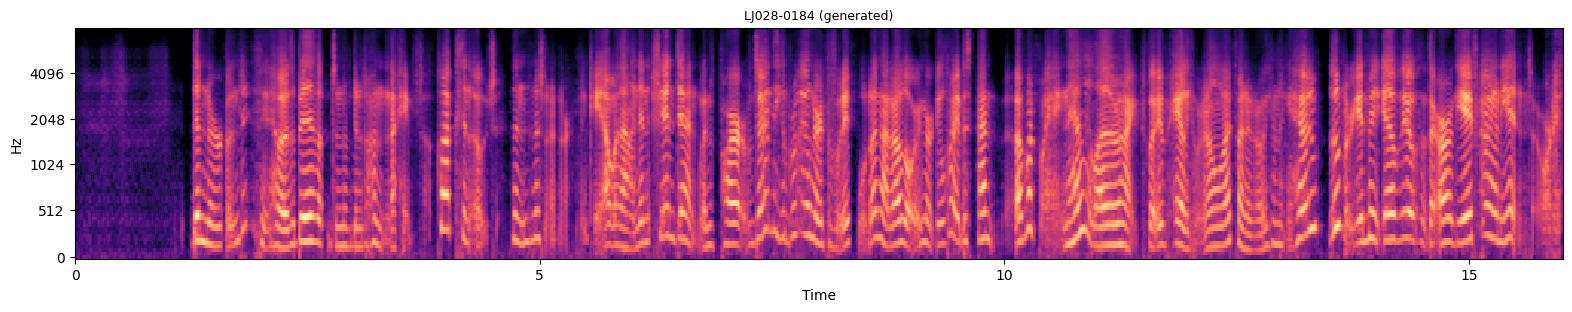

In [20]:
# inference
text = "The quick brown fox jumps over the lazy dog."

def sample_tts(text, max_new=400, temperature=0.9, top_k=100):
    model_device = next(tts.parameters()).device
    text_ids = torch.tensor(tokenizer.encode(text, add_special_tokens=False), device=model_device)
    toks = tts.generate_audio(text_ids, max_new_tokens=max_new, temperature=temperature, top_k=top_k)
    if toks.numel() == 0: return np.zeros(CODEC_SR // 2, dtype=np.float32), toks
    with torch.no_grad():
        wav = codec.toks_to_sig(toks.unsqueeze(0)).squeeze(0).detach().cpu().numpy().astype(np.float32)
    return wav, toks

wav, toks = sample_tts(text)
print(f'{toks.numel()} tokens, {wav.shape[-1]/CODEC_SR:.2f}s')
print(f'  text: {text}')
plot_mel(wav, CODEC_SR, f'{row["id"]} (generated)')
import IPython.display as ipd
ipd.display(ipd.Audio(wav, rate=CODEC_SR))

# Homework

In [21]:
# === Train (Lightning) ===
# Uses LitGPT2TTS from the earlier cell.

# Quiet noisy warnings in notebooks
import warnings
warnings.filterwarnings('ignore', message=r".*Loading widget.*")
warnings.filterwarnings('ignore', message=r".*is deprecated, use `isinstance\(treespec, TreeSpec\).*\)")
warnings.filterwarnings('ignore', message=r".*Found .* module\(s\) in eval mode.*")
warnings.filterwarnings('ignore', message=r".*lr_scheduler\.step\(\).*before.*optimizer\.step\(\).*", category=UserWarning)

lit = LitGPT2TTS(tts, lr=2e-4, warmup_steps=200, max_steps=2000)

# Kaggle often has very limited disk space in /kaggle/working.
# To avoid crashes from TensorBoard logs / checkpoints, disable logger & checkpointing.
logger = False

# IMPORTANT: LearningRateMonitor requires a logger, so we must not use it when logger=False.
callbacks = []

trainer = L.Trainer(
    max_steps=2000,
    precision='16-mixed',
    callbacks=callbacks,
    logger=logger,
    enable_checkpointing=False,
    log_every_n_steps=1,
    val_check_interval=1.0,  # end of epoch
)

trainer.fit(lit, train_dataloaders=train_dl, val_dataloaders=val_dl)
print('training done (checkpointing disabled to save disk)')


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Usi

┏━━━┳━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ tts  │ GPT2TTS │  137 M │ train │     0 │
└───┴──────┴─────────┴────────┴───────┴───────┘

Trainable params: 137 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 137 M                                                                                                
Total estimated model params size (MB): 548                                                                        
Modules in train mode: 167                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_steps=2000` reached.


training done (checkpointing disabled to save disk)


In [22]:
# Inference helpers: sampling sweeps
import numpy as np
import torch

@torch.no_grad()
def sample_tts_with_params(text, max_new=400, temperature=0.9, top_k=50):
    # Always match *model* device (don't rely on global `device` after moving `tts` around)
    model_device = next(tts.parameters()).device
    text_ids = torch.tensor(
        tokenizer.encode(text, add_special_tokens=False),
        device=model_device,
    )
    toks = tts.generate_audio(text_ids, max_new_tokens=max_new, temperature=temperature, top_k=top_k)
    if toks.numel() == 0:
        return np.zeros(CODEC_SR // 2, dtype=np.float32), toks
    wav = codec.toks_to_sig(toks.unsqueeze(0)).squeeze(0).detach().cpu().numpy().astype(np.float32)
    return wav, toks

In [23]:
# Inference helpers: sampling sweeps
import numpy as np
import torch

@torch.no_grad()
def sample_tts_with_params(text, max_new=400, temperature=0.9, top_k=50):
    # Always match *model* device (don't rely on global `device` after moving `tts` around)
    model_device = next(tts.parameters()).device
    text_ids = torch.tensor(
        tokenizer.encode(text, add_special_tokens=False),
        device=model_device,
    )
    toks = tts.generate_audio(text_ids, max_new_tokens=max_new, temperature=temperature, top_k=top_k)
    if toks.numel() == 0:
        return np.zeros(CODEC_SR // 2, dtype=np.float32), toks

    # FocalCodec buffers may live on CPU; ensure tokens on the same device as the codec
    codec_device = next(codec.parameters()).device
    toks = toks.to(codec_device)
    wav = (
        codec.toks_to_sig(toks.unsqueeze(0))
        .squeeze(0)
        .detach()
        .cpu()
        .numpy()
        .astype(np.float32)
    )
    return wav, toks

In [24]:
# Fix for: AttributeError: 'function' object has no attribute 'Audio'
# This happens when the name `display` is shadowed.
import IPython.display as ipd

# Use:
# ipd.Audio(wav, rate=CODEC_SR)
# ipd.display(ipd.Audio(wav, rate=CODEC_SR))


In [25]:
# === Inference on a text set with different sampling ===
texts = [
    "The quick brown fox jumps over the lazy dog.",
    "Neural audio codecs discretize speech into tokens.",
    "This notebook trains a small LM to generate codec tokens from text.",
]

sampling_grid = [
    dict(temperature=0.7, top_k=20),
    dict(temperature=0.9, top_k=50),
    dict(temperature=1.0, top_k=100),
]

gens = []
for t in texts:
    for p in sampling_grid:
        wav, toks = sample_tts_with_params(t, max_new=400, **p)
        gens.append({'text': t, **p, 'wav': wav, 'toks': toks})

print('generated:', len(gens))
# play first sample
import IPython.display as ipd
ipd.display(ipd.Audio(gens[0]['wav'], rate=CODEC_SR))

generated: 9


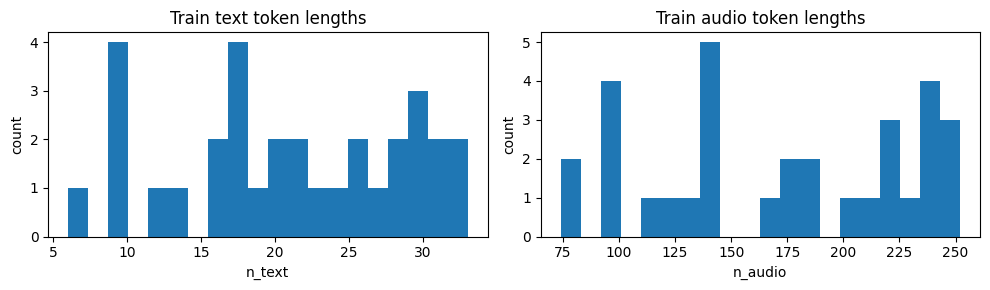

In [26]:
# === Extra plots: dataset token length distributions ===
import matplotlib.pyplot as plt
import numpy as np

# train_items/val_items are created in the tokenization cell
if 'train_items' in globals() and train_items is not None:
    a = np.array([r['n_audio'] for r in train_items])
    t = np.array([r['n_text'] for r in train_items])

    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].hist(t, bins=20)
    ax[0].set_title('Train text token lengths')
    ax[0].set_xlabel('n_text')
    ax[0].set_ylabel('count')

    ax[1].hist(a, bins=20)
    ax[1].set_title('Train audio token lengths')
    ax[1].set_xlabel('n_audio')
    ax[1].set_ylabel('count')
    plt.tight_layout()
    plt.show()
else:
    print('Run tokenization cell first (train_items/val_items).')


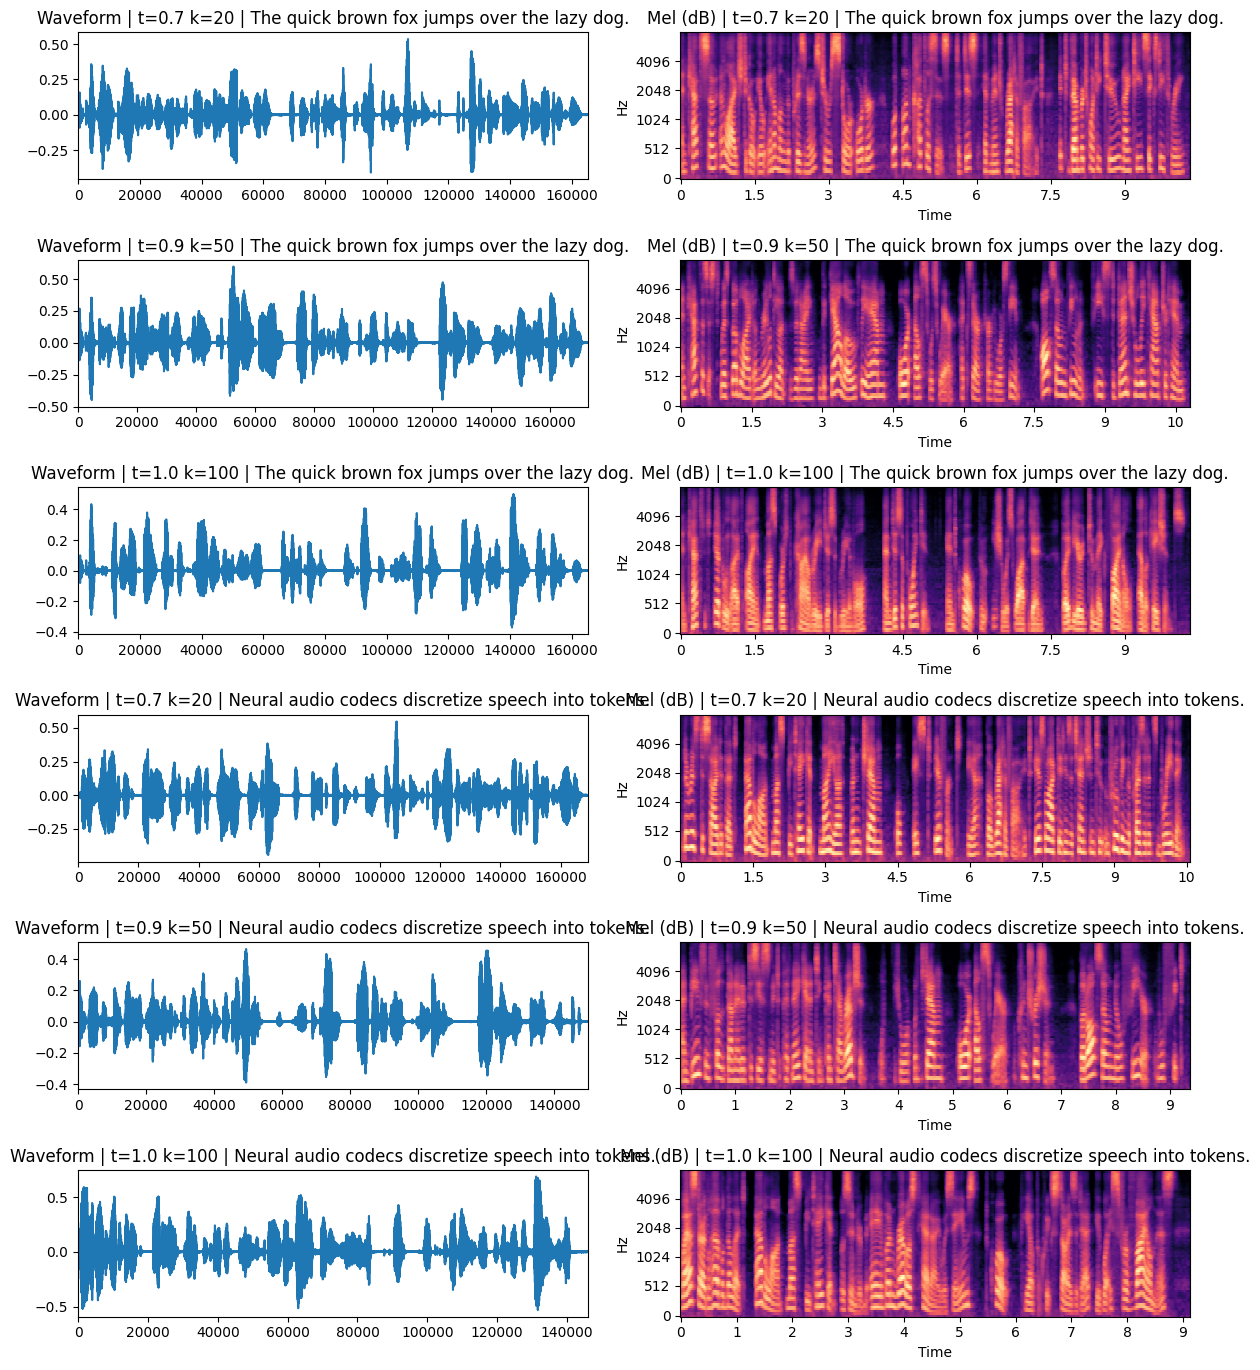

In [27]:
# === Extra plots: sampling comparison (mel + waveform) ===
import matplotlib.pyplot as plt

# gens is created in the inference sweep cell
if 'gens' in globals() and len(gens) > 0:
    N = min(6, len(gens))
    fig, ax = plt.subplots(N, 2, figsize=(12, 2.3 * N))
    if N == 1:
        ax = np.array([ax])

    for i in range(N):
        wav = gens[i]['wav']
        title = f"t={gens[i]['temperature']} k={gens[i]['top_k']} | {gens[i]['text'][:50]}" + ('...' if len(gens[i]['text']) > 50 else '')

        # waveform
        ax[i, 0].plot(wav)
        ax[i, 0].set_title('Waveform | ' + title)
        ax[i, 0].set_xlim(0, len(wav))

        # mel (use existing plot_mel if present; otherwise a fallback)
        if 'plot_mel' in globals():
            # plot_mel shows its own figure; do a lightweight mel fallback here
            import librosa
            import librosa.display
            S = librosa.feature.melspectrogram(y=wav, sr=CODEC_SR, n_mels=80, hop_length=256)
            S_db = librosa.power_to_db(S, ref=np.max)
            img = librosa.display.specshow(S_db, sr=CODEC_SR, hop_length=256, x_axis='time', y_axis='mel', ax=ax[i, 1])
            ax[i, 1].set_title('Mel (dB) | ' + title)
        else:
            ax[i, 1].text(0.5, 0.5, 'plot_mel not defined', ha='center', va='center')

    plt.tight_layout()
    plt.show()
else:
    print('Run inference sweep cell first (gens).')


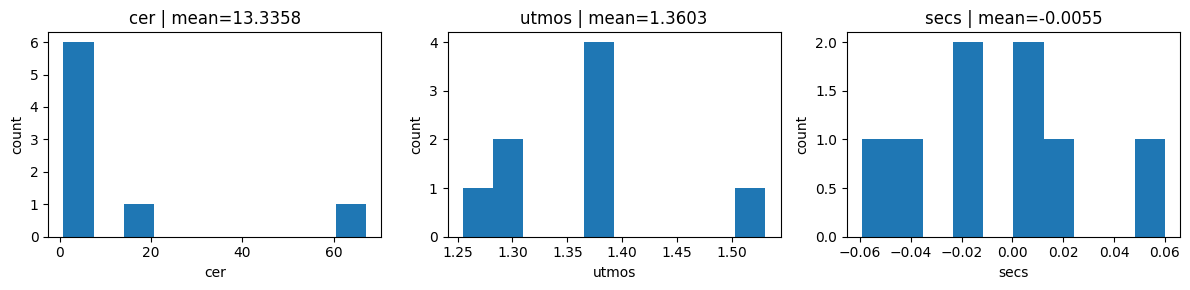

In [28]:
# === Extra plots: metric distributions ===
import matplotlib.pyplot as plt
import numpy as np

if 'results' in globals() and results is not None and len(results) > 0:
    def _get(key):
        vals = [r.get(key, None) for r in results]
        vals = [v for v in vals if v is not None]
        return np.array(vals, dtype=np.float32) if len(vals) else None

    cer_vals = _get('cer')
    utmos_vals = _get('utmos')
    secs_vals = _get('secs')

    keys = [('cer', cer_vals), ('utmos', utmos_vals), ('secs', secs_vals)]
    keys = [(k, v) for k, v in keys if v is not None]

    if len(keys) == 0:
        print('No numeric metrics in results yet (run eval cell, and ensure deps installed).')
    else:
        fig, ax = plt.subplots(1, len(keys), figsize=(4 * len(keys), 3))
        if len(keys) == 1:
            ax = [ax]
        for i, (k, v) in enumerate(keys):
            ax[i].hist(v, bins=10)
            ax[i].set_title(f"{k} | mean={v.mean():.4f}")
            ax[i].set_xlabel(k)
            ax[i].set_ylabel('count')
        plt.tight_layout()
        plt.show()
else:
    print('Run eval cell first (results).')


Theory:
Answer theory questions in the Google Form.

Practice:

1. Complete the gptTTS code 
1. Put together training pipeline with torch or lightning 
1. Train gpt2 for TTS task
1. Run inference with different sampling strategies on several texts
1. Compute CER; UTMOS; SECS from xTTS paper (you can use xTTS's library)

In [29]:
# === Analytics: make a DataFrame from generations + metrics ===
import pandas as pd
import numpy as np

# Build rows from gens (sampling sweep)
rows = []
if 'gens' in globals():
    for i,g in enumerate(gens):
        rows.append({
            'gen_idx': i,
            'text': g.get('text'),
            'temperature': g.get('temperature'),
            'top_k': g.get('top_k'),
            'n_samples': len(g.get('wav', [])),
            'n_audio_tokens': int(g.get('toks').numel()) if 'toks' in g and g['toks'] is not None else None,
        })

df_gen = pd.DataFrame(rows)
print('df_gen:', df_gen.shape)
df_gen.head()

df_gen: (9, 6)


,gen_idx,text,temperature,top_k,n_samples,n_audio_tokens
0,0,The quick brown fox jumps over the lazy dog.,0.7,20,165120,258
1,1,The quick brown fox jumps over the lazy dog.,0.9,50,172800,270
2,2,The quick brown fox jumps over the lazy dog.,1.0,100,165120,258
3,3,Neural audio codecs discretize speech into tok...,0.7,20,168960,264
4,4,Neural audio codecs discretize speech into tok...,0.9,50,149760,234


,id,text,temperature,top_k,n_audio_tokens,asr_hyp,cer,utmos,secs
0,LJ003-0083,"Each ward was calculated to hold twenty-four, ...",0.9,50,400,I don't know if he's there for the first child...,20.593407,1.378115,0.010117
1,LJ048-0091,Advance preparations.,0.9,50,400,"Det var en av de där, det var bara 5, det var ...",67.142857,1.254635,-0.021922
2,LJ021-0089,and have effected a reorganization of the N.R.A.,0.9,50,400,do,0.958333,1.292186,0.016425
3,LJ050-0258,Much of the Secret Service work requires the d...,0.9,50,400,"Yn ymwneud, yw'r ffordd, yn ymwneud, yn ymwneu...",7.212121,1.530494,0.060020
4,LJ033-0151,identified these prints as the left index fing...,0.9,50,400,I'm not sure what you were thinking about.,0.819149,1.377312,-0.014745


,count,mean,std,min,25%,50%,75%,max
cer,8.0,13.335803,22.697110,0.774194,0.923537,4.593183,10.557443,67.142857
utmos,8.0,1.360345,0.084624,1.254635,1.295649,1.372127,1.380155,1.530494
secs,8.0,-0.005510,0.037561,-0.059256,-0.027233,-0.003148,0.011694,0.060020


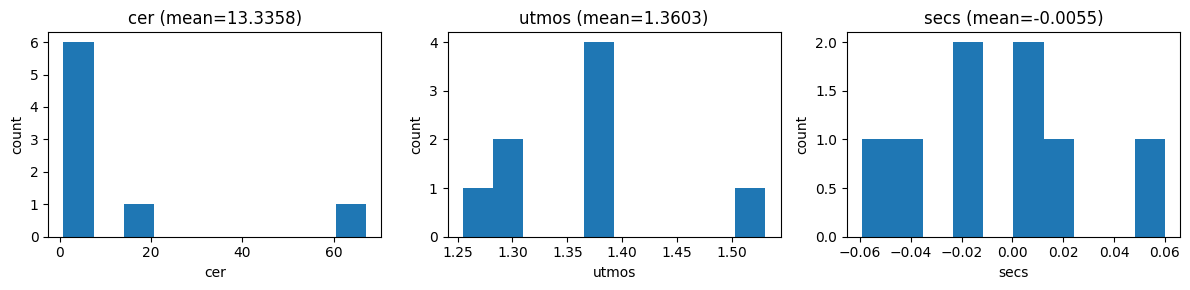

In [30]:
# === Analytics: metrics summary + distribution plots ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

if 'results' in globals() and results is not None and len(results) > 0:
    df = pd.DataFrame(results)
    display(df.head())

    # numeric summary
    num_cols = [c for c in ['cer','utmos','secs'] if c in df.columns]
    display(df[num_cols].describe().T)

    # histograms
    fig, ax = plt.subplots(1, len(num_cols), figsize=(4*len(num_cols), 3))
    if len(num_cols) == 1:
        ax = [ax]
    for i,c in enumerate(num_cols):
        vals = df[c].dropna().astype(float)
        ax[i].hist(vals, bins=10)
        ax[i].set_title(f"{c} (mean={vals.mean():.4f})")
        ax[i].set_xlabel(c)
        ax[i].set_ylabel('count')
    plt.tight_layout(); plt.show()

else:
    print('Run eval cell first to produce `results`.')


In [31]:
# === Analytics: correlations and worst/best examples (CER) ===
import pandas as pd
import numpy as np

if 'results' in globals() and results is not None and len(results) > 0:
    df = pd.DataFrame(results)

    # correlations (numeric only)
    cols = [c for c in ['cer','utmos','secs'] if c in df.columns]
    if len(cols) >= 2:
        corr = df[cols].astype(float).corr(method='spearman')
        print('Spearman correlation:')
        display(corr)
    else:
        print('Not enough numeric metric columns for correlation.')

    # show best/worst by CER
    if 'cer' in df.columns:
        tmp = df[['id','cer','asr_hyp']].copy()
        tmp['cer'] = pd.to_numeric(tmp['cer'], errors='coerce')
        tmp = tmp.dropna(subset=['cer']).sort_values('cer')
        print('Best (lowest CER):')
        display(tmp.head(5))
        print('Worst (highest CER):')
        display(tmp.tail(5))
else:
    print('Run eval cell first to produce `results`.')


Spearman correlation:


,cer,utmos,secs
cer,1.000000,0.142857,0.357143
utmos,0.142857,1.000000,0.500000
secs,0.357143,0.500000,1.000000


Best (lowest CER):


,id,cer,asr_hyp
7,LJ028-0184,0.774194,"The ruggish, more coverage."
4,LJ033-0151,0.819149,I'm not sure what you were thinking about.
2,LJ021-0089,0.958333,do
6,LJ007-0072,4.268456,Þúður að mýlægja og þessum sérðin að var hyss ...
5,LJ019-0187,4.917910,I thought we had to do-do-do-do-do-do-do-do-do...


Worst (highest CER):


,id,cer,asr_hyp
6,LJ007-0072,4.268456,Þúður að mýlægja og þessum sérðin að var hyss ...
5,LJ019-0187,4.917910,I thought we had to do-do-do-do-do-do-do-do-do...
3,LJ050-0258,7.212121,"Yn ymwneud, yw'r ffordd, yn ymwneud, yn ymwneu..."
0,LJ003-0083,20.593407,I don't know if he's there for the first child...
1,LJ048-0091,67.142857,"Det var en av de där, det var bara 5, det var ..."


In [32]:
# === Analytics: sampling comparison via CER/UTMOS/SECS (if you evaluate per-sample) ===
# If you want per-sampling analytics, we need to evaluate metrics for each (text, sampling) generation.
# This cell builds a template loop to do that on a small subset.

import pandas as pd

import logging
for name in (
    "speechbrain",
    "speechbrain.utils.fetching",
    "speechbrain.utils.parameter_transfer",
    "huggingface_hub",
    "huggingface_hub.file_download",
):
    logging.getLogger(name).setLevel(logging.WARNING) 

EVAL_TEXTS = [
    "The quick brown fox jumps over the lazy dog.",
    "Neural audio codecs discretize speech into tokens.",
]

sampling_grid = [
    dict(temperature=0.7, top_k=20),
    dict(temperature=0.9, top_k=50),
    dict(temperature=1.0, top_k=100),
]

if 'WhisperASR' not in globals():
    print('Run the metrics cell first (WhisperASR).')
else:
    asr = WhisperASR(device=device)
    # optional scorers
    utmos_scorer = None
    if 'UTMOS' in globals() and UTMOS is not None:
        try:
            utmos_scorer = UTMOS(device=device)
        except Exception as e:
            print('UTMOS init failed:', e)

    secs_scorer = None
    if 'SECS' in globals() and 'EncoderClassifier' in globals() and EncoderClassifier is not None:
        try:
            secs_scorer = SECS(device=device)
        except Exception as e:
            print('SECS init failed:', e)

    per = []
    for text in EVAL_TEXTS:
        for p in sampling_grid:
            wav, toks = sample_tts_with_params(text, max_new=400, **p)
            hyp = asr.transcribe(wav, CODEC_SR)
            row = {
                'text': text,
                **p,
                'n_audio_tokens': int(toks.numel()),
                'cer': compute_cer(text, hyp),
                'utmos': None,
            }
            if utmos_scorer is not None:
                try:
                    row['utmos'] = float(utmos_scorer.score(wav, CODEC_SR))
                except Exception:
                    row['utmos'] = None
            # SECS needs a reference speaker wav; LJ Speech is single-speaker so you can use any fixed ref wav
            per.append(row)

    df_per = pd.DataFrame(per)
    display(df_per)

    agg_cols = [c for c in ['cer', 'utmos'] if c in df_per.columns]
    if len(agg_cols) == 0:
        print('Nothing to aggregate.')
    else:
        display(df_per.groupby(['temperature', 'top_k'])[agg_cols].mean(numeric_only=True).reset_index())


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

,text,temperature,top_k,n_audio_tokens,cer,utmos
0,The quick brown fox jumps over the lazy dog.,0.7,20,259,2.659091,None
1,The quick brown fox jumps over the lazy dog.,0.9,50,242,2.750000,None
2,The quick brown fox jumps over the lazy dog.,1.0,100,258,3.159091,None
3,Neural audio codecs discretize speech into tok...,0.7,20,242,2.340000,None
4,Neural audio codecs discretize speech into tok...,0.9,50,240,2.460000,None
5,Neural audio codecs discretize speech into tok...,1.0,100,259,2.620000,None


,temperature,top_k,cer
0,0.7,20,2.499545
1,0.9,50,2.605000
2,1.0,100,2.889545
